# Stage 12B — Robustness Exploration

**Research question:** Does the baseline conclusion depend on reasonable methodological choices?

We vary event thresholds, horizons, return definitions, universe membership, and extreme-observation treatment one dimension at a time.

## Methodology

This is an exploratory specification map, not final robustness or parameter optimization. The market-adjusted row is retained as unavailable because Stage 11D contains no broad-market benchmark. The questionable-security exclusion is identical to core because the reviewed universe contains no questionable names.

In [1]:
from IPython.display import Image, display
from price_diffusion.research_diagnostics import load_diagnostic_inputs, run_robustness_exploration

inputs = load_diagnostic_inputs()
artifacts = run_robustness_exploration(inputs)

In [2]:
comparison = artifacts.tables['specification_comparison']
display(comparison)
display(comparison.groupby(['variation_type', 'specification', 'status'], dropna=False)['sample_size'].max())

,variation_type,specification,horizon,outcome,event_count,sample_size,mean,median,ci_lower,ci_upper,sample_label,status,notes
0,event_threshold,2_sigma,1,convergence,319,319,0.005304,0.002901,0.000996,0.009612,adequate_descriptive_sample,estimated_exploratory,minimum absolute move remains 5%; all other ru...
1,event_threshold,2_sigma,1,peer_catchup,319,319,0.001256,-0.000422,-0.000769,0.003280,adequate_descriptive_sample,estimated_exploratory,minimum absolute move remains 5%; all other ru...
2,event_threshold,2_sigma,1,initiator_reversal,319,319,0.004048,0.003729,0.000116,0.007981,adequate_descriptive_sample,estimated_exploratory,minimum absolute move remains 5%; all other ru...
3,event_threshold,2_sigma,3,convergence,274,274,0.007305,0.005125,0.001598,0.013012,adequate_descriptive_sample,estimated_exploratory,minimum absolute move remains 5%; all other ru...
4,event_threshold,2_sigma,3,peer_catchup,274,274,0.002566,0.000056,-0.000318,0.005451,adequate_descriptive_sample,estimated_exploratory,minimum absolute move remains 5%; all other ru...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,extreme_event_treatment,exclude_flagged_extremes,5,peer_catchup,171,171,0.002321,-0.000915,-0.001800,0.006441,adequate_descriptive_sample,estimated_exploratory,excludes convergence outside three IQRs within...
182,extreme_event_treatment,exclude_flagged_extremes,5,initiator_reversal,171,171,0.001692,-0.000888,-0.004736,0.008121,adequate_descriptive_sample,estimated_exploratory,excludes convergence outside three IQRs within...
183,extreme_event_treatment,exclude_flagged_extremes,10,convergence,114,114,-0.001476,-0.004646,-0.015727,0.012776,adequate_descriptive_sample,estimated_exploratory,excludes convergence outside three IQRs within...
184,extreme_event_treatment,exclude_flagged_extremes,10,peer_catchup,114,114,0.002647,0.002730,-0.004864,0.010158,adequate_descriptive_sample,estimated_exploratory,excludes convergence outside three IQRs within...


variation_type           specification                  status               
event_threshold          2.5_sigma                      estimated_exploratory    282
                         2_sigma                        estimated_exploratory    319
                         3_sigma                        estimated_exploratory    226
                         4_sigma                        estimated_exploratory    157
extreme_event_treatment  all_events                     estimated_exploratory    226
                         exclude_flagged_extremes       estimated_exploratory    219
                         winsorized_1_99                estimated_exploratory    226
return_definition        market_adjusted                unavailable                0
                         raw_returns                    estimated_exploratory    226
                         semiconductor_factor_adjusted  estimated_exploratory    226
universe                 core                           estimated_explor

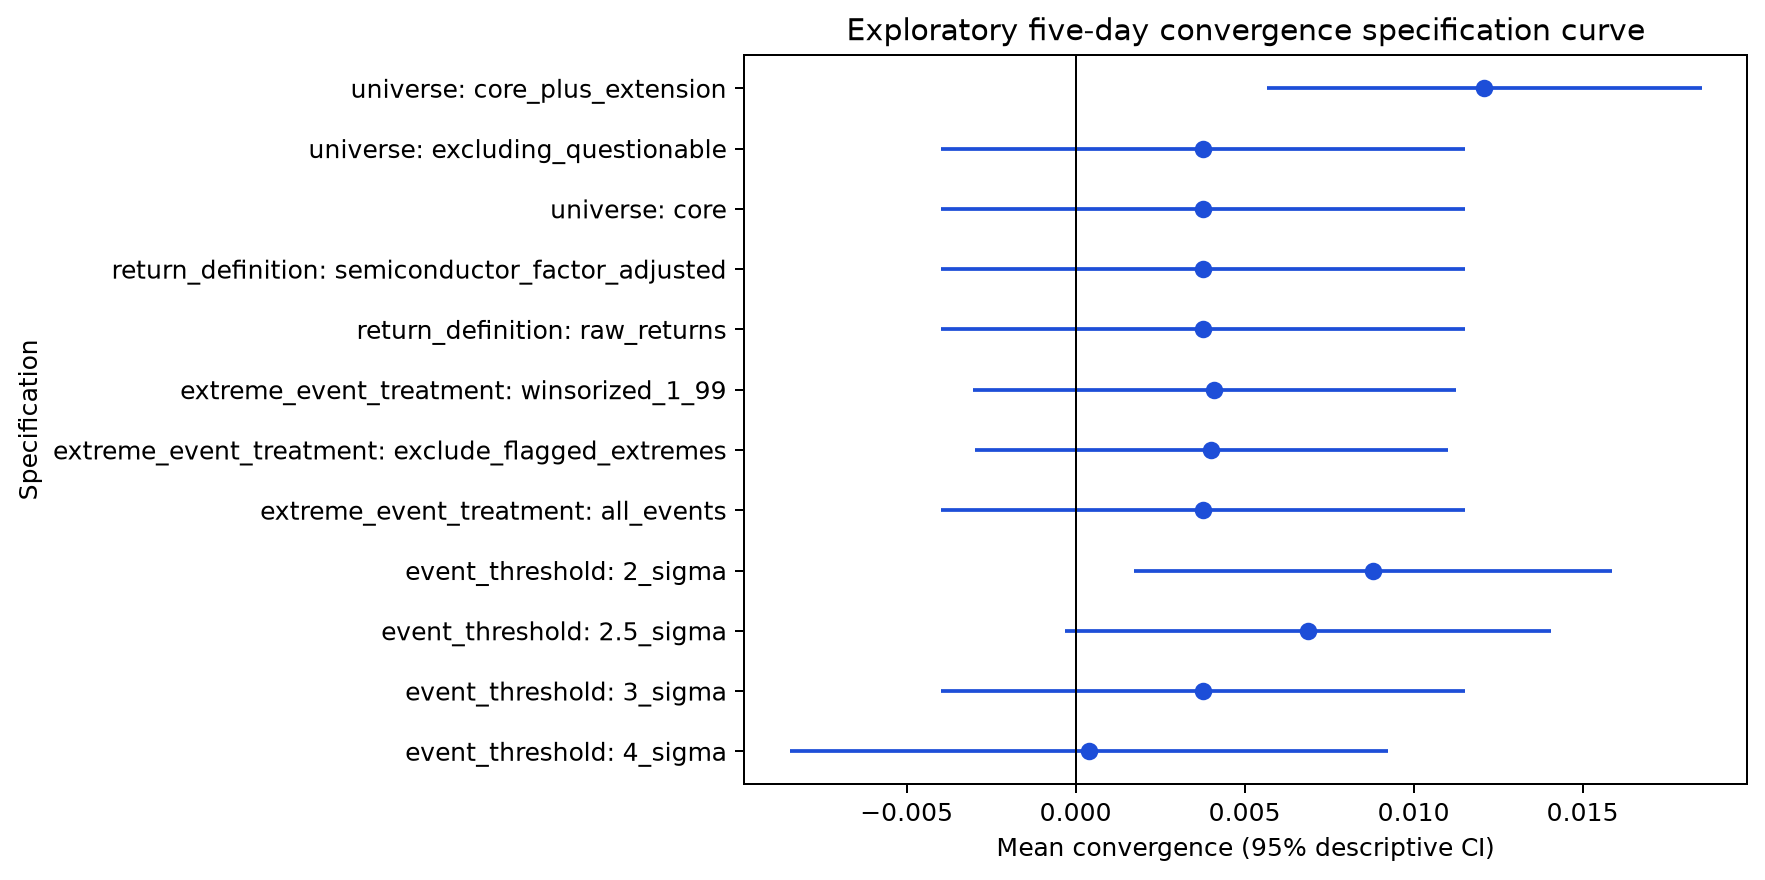

In [3]:
display(Image(filename=str(artifacts.paths['specification_curve'])))

## Interpretation

A robust descriptive conclusion should not flip solely because of a nearby threshold or mild tail treatment. Any apparent pocket of strength should be preregistered and tested on untouched data in Stage 13.